In [10]:
import pandas as pd
import matplotlib.pyplot as plt



In [11]:
df = pd.read_csv(r"C:\Users\myjyu\OneDrive\Desktop\netflix_data_analysis\cleaned_netflix.csv")

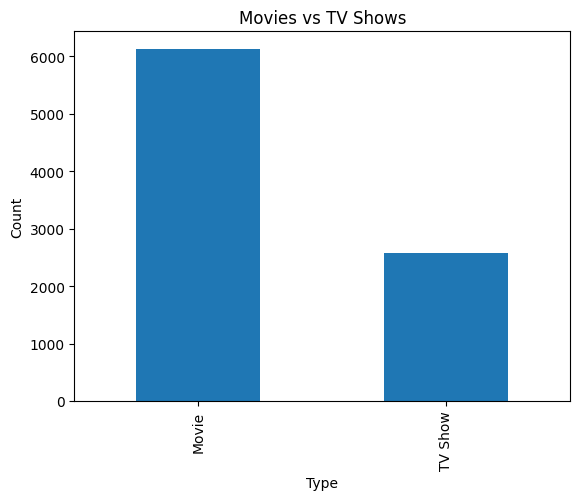

In [12]:
type_counts = df['type'].value_counts()

type_counts.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

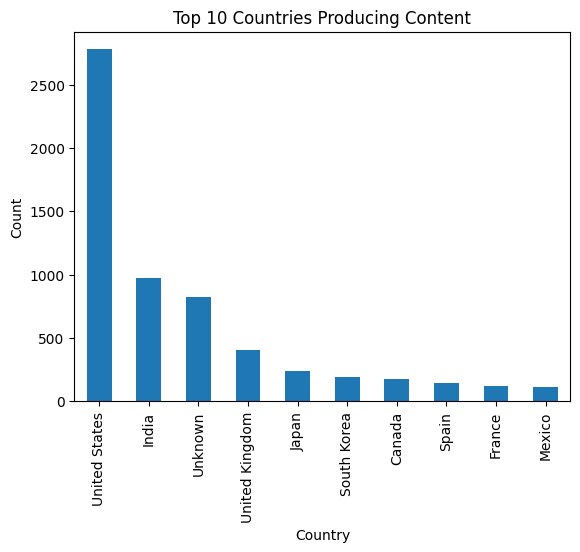

In [13]:
top_countries = df['country'].value_counts().head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries Producing Content")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()

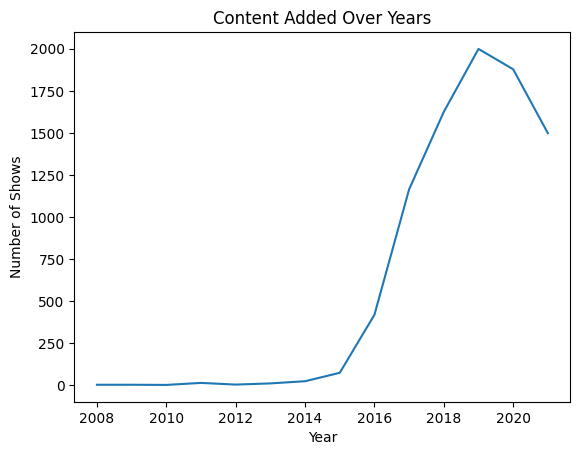

In [14]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

year_data = df['year_added'].value_counts().sort_index()

year_data.plot()
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Shows")
plt.show()

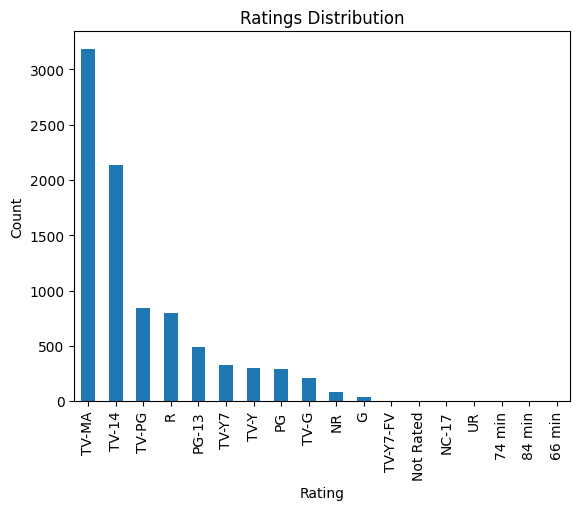

In [15]:
ratings = df['rating'].value_counts()

ratings.plot(kind='bar')
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

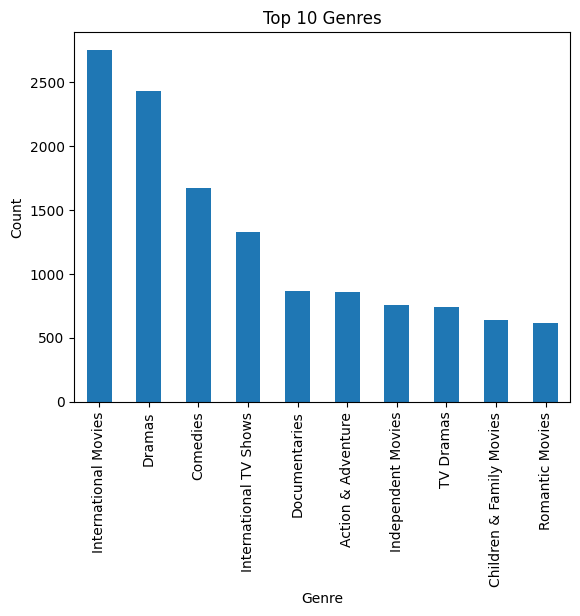

In [16]:
genres = df['listed_in'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(10)

top_genres.plot(kind='bar')
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [17]:

df = df.copy()
df.drop_duplicates(inplace=True)
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)
df_genres = df.copy()
df_genres['listed_in'] = df_genres['listed_in'].str.split(', ')
df_genres = df_genres.explode('listed_in')
df_genres = df_genres.dropna(subset=['listed_in'])
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,1.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,2.0


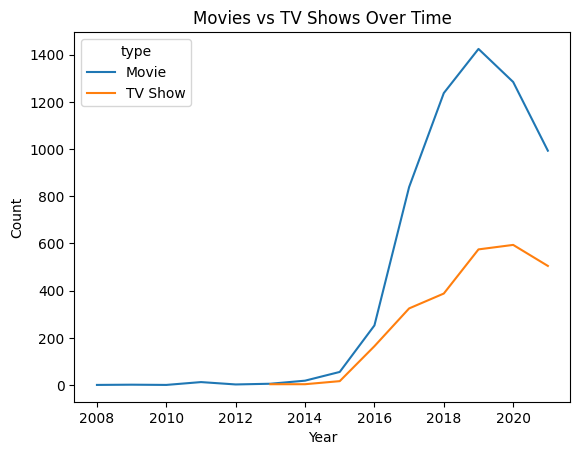

In [18]:
type_year = df.groupby(['year_added', 'type']).size().unstack()

type_year.plot()
plt.title("Movies vs TV Shows Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

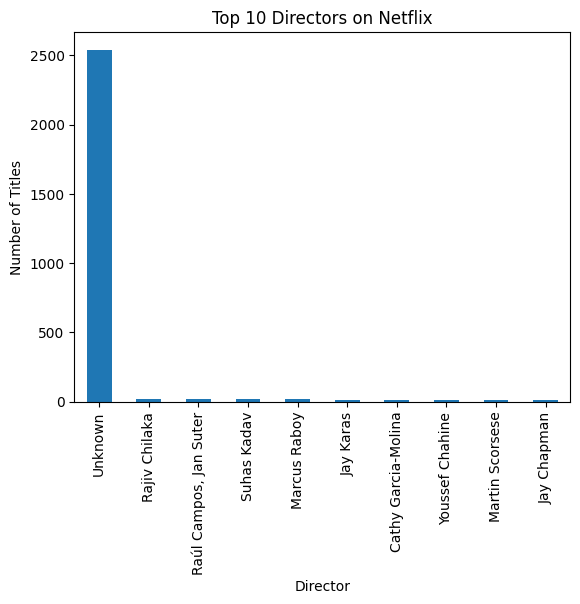

In [19]:
top_directors = df['director'].value_counts().head(10)
top_directors.plot(kind='bar')
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.show()

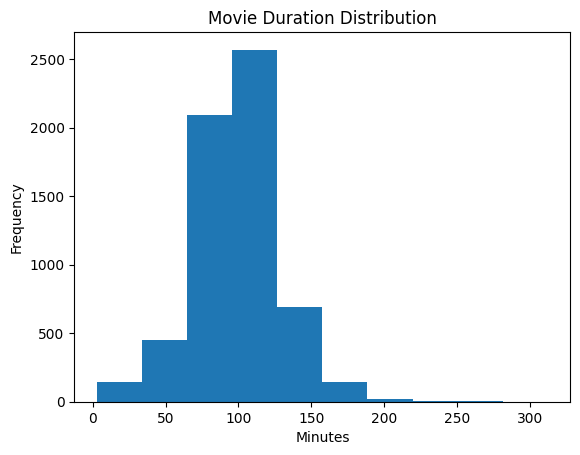

In [20]:
movies = df[df['type'] == 'Movie']

movies['duration_num'].plot(kind='hist')
plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

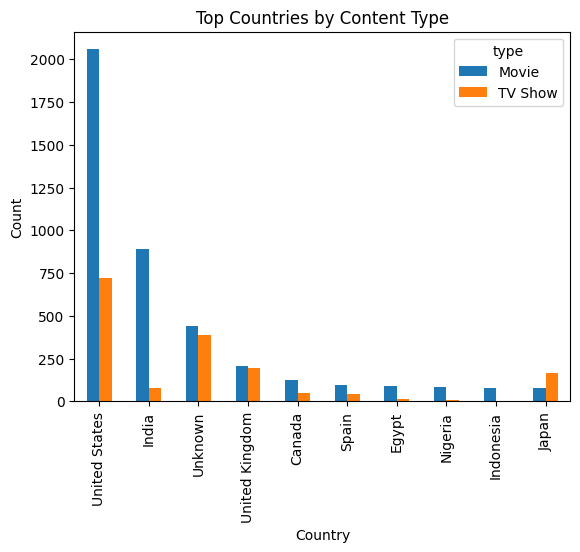

In [21]:
country_type = df.groupby(['country', 'type']).size().unstack().fillna(0)
top_country = country_type.sort_values(by='Movie', ascending=False).head(10)

top_country.plot(kind='bar')
plt.title("Top Countries by Content Type")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()